In [2]:
%pip install matplotlib numpy pandas scikit-learn 

Note: you may need to restart the kernel to use updated packages.


## **Conceitos de Classificação**

Dados: Dataset MNIST-784, que contem 70000 imagens preto em brancas de tamanho 28x28, ou seja, flated temos 784 features (pixeis que variam de 0 a 255), já vem preprocessado e separado.

In [3]:
from sklearn.datasets import fetch_openml

mnist = fetch_openml('mnist_784', as_frame=False)
mnist.keys()

dict_keys(['data', 'target', 'frame', 'categories', 'feature_names', 'target_names', 'DESCR', 'details', 'url'])

In [4]:
X, y = mnist.data,mnist.target

print(X.shape)
print(y.shape)

X_train, X_test, y_train, y_test = X[:60000], X[60000:], y[:60000], y[60000:]

(70000, 784)
(70000,)


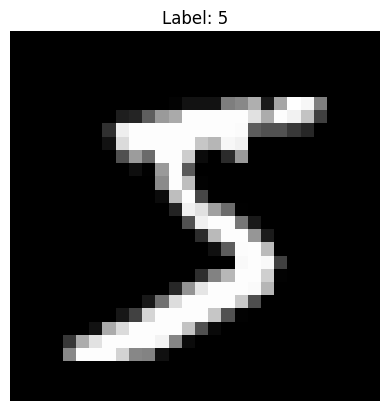

In [5]:
from matplotlib import pyplot as plt

plt.imshow(X[0].reshape(28, 28), cmap='gray') 
# reshape para transformar o vetor de 784 pixels em uma imagem 28x28, e cmap='gray' para exibir a imagem em escala de cinza.

plt.title(f"Label: {y[0]}")
plt.axis('off')
plt.show()

### **Classificação Binária**

Podemos por simplicidade treinar um modelo de classificação binária em queremos classificar se o digito é 7 ou não é 7... teremos apenas essas 2 opções. 

In [6]:
y_train_7 =  (y_train == '7')
y_test_7 =  (y_test == '7') # geramos vetores target booleanos 

from sklearn.linear_model import SGDClassifier

sgdclass_model = SGDClassifier(random_state=42) # muito util para grandes datasets, pois processa os dados em mini-batches, 
#o que reduz o uso de memória e pode acelerar o treinamento. Além disso, util em treino online pois pode ser atualizado com 
# novos dados sem precisar ser re-treinado do zero.
# Stocastic -> atualiza os pesos do modelo para cada amostra de treinamento
# Batch -> atualiza os pesos do modelo apenas após processar todo o conjunto de treinamento
# Mini-batch -> atualiza os pesos do modelo após processar um pequeno lote de amostras de treinamento (mini-batch)

sgdclass_model.fit(X_train, y_train_7)

print(sgdclass_model.predict(X[10:30]))
print(y[10:30])


[False False False False False  True False False False False False False
 False False False False False False False  True]
['3' '5' '3' '6' '1' '7' '2' '8' '6' '9' '4' '0' '9' '1' '1' '2' '4' '3'
 '2' '7']


#### **Métricas de performace:**

- **Acurácia:** Representa quantas inferências acertamos (0 ou 1) em relacao ao total, se acertamos 9 de um total de 10 temos acuracia 9/10. O problema da acurácia é que ela pode ser facilmente enganosa pela distribuicao das classes pois imagine que apenas 10% dos dados é da classe positiva. Se um modelo simples que apenas retorna falso for usado ele vai ter acurácia de 90% que pode ser mal interpretado como um modelo otimo.

In [7]:

from sklearn.model_selection import cross_val_score
from sklearn.dummy import DummyClassifier 
# DummyClassifier é um modelo de classificação que faz previsões aleatórias ou baseadas em uma estratégia simples, como a classe mais frequente. 
# ele é usado como um modelo de referência (baseline) para comparar o desempenho de outros modelos de classificação.

acuracia = cross_val_score(sgdclass_model, X_train, y_train_7, cv=3, scoring='accuracy')
print(acuracia.mean())

dummy_clf = DummyClassifier(strategy='most_frequent', random_state=42)
dummy_clf.fit(X_train, y_train_7)
dummy_acuracia = cross_val_score(dummy_clf, X_train, y_train_7, cv=3, scoring='accuracy')
print(dummy_acuracia.mean())

# a acuracia do modelo Dummy é de quase 90%, enquanto do outro é 97%.
# significa que o modelo nao é tao bom quanto parece, pois ele tem um desempenho muito proximo do modelo Dummy, que é um modelo de referencia.


0.9708333333333333
0.8955833333333333


- **Matriz de Confusao:** Uma matriz que mostra para cada classe X a quantidade/proporção de itens classificados em outras classes quando deveria ser na classe X. 

[[52389  1346]
 [  404  5861]]


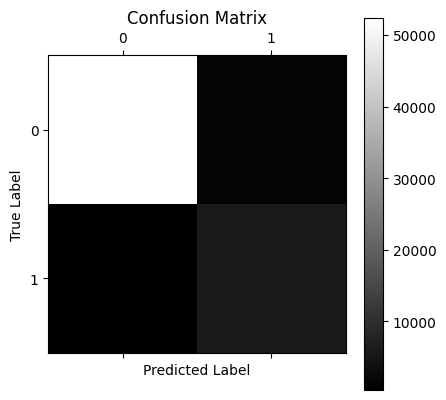

In [8]:
from sklearn.metrics import confusion_matrix
from sklearn.model_selection import cross_val_predict
from matplotlib import pyplot as plt

y_train_7_pred = cross_val_predict(sgdclass_model, X_train, y_train_7, cv=3)
conf_matrix = confusion_matrix(y_train_7, y_train_7_pred) # retorna na ordem classe negativa (False) e classe positiva (True)

print(conf_matrix)

plt.matshow(conf_matrix, cmap=plt.cm.gray)
plt.title("Confusion Matrix")
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.colorbar()
plt.show()

# Como o retoro é na ordem classe negativa (False) e classe positiva (True), a matriz de confusão é interpretada da seguinte forma:
# [0,0] -> True Negatives (TN): número de vezes que o modelo previu corretamente a classe negativa (False). (52389)
# [0,1] -> False Positives (FP): número de vezes que o modelo previu incorretamente a classe positiva (True) quando a classe real era negativa (False). (1346)
# [1,0] -> False Negatives (FN): número de vezes que o modelo previu incorretamente a classe negativa (False) quando a classe real era positiva (True). (404)
# [1,1] -> True Positives (TP): número de vezes que o modelo previu corretamente a classe positiva (True). (5861)

- **Precisao:** Aqui estamos medindo quantas das previsoes na classe A de todas as previsoes na classe A voce acertou... por exemplo a precisao da classe positiva (7) é o quanto eu previ corretamente 7, ou seja, TP dividido pelo total que eu previ ser positivo, ou seja, TP + FP... -> P = TP/ (TP + FP). 

$$P =  \frac{TP}{TP + FP}$$

- **Recall:** Aqui queremos saber o quanto acertamos na classe A em relacao a quantos eram realmente daquela classe... por exemplo o recall da classe positiva é o quanto eu previ corretamente da classe 7, ou seja, TP dividido pelo total que existia naquela classe, ou seja, TP + FN (quantos positivos acertamos mais quantos positivos erramos) -> R =  TP/ (TP + FN). 

$$R =  \frac{TP}{TP + FN}$$

**OBS:** Ambas as métricas podem ser expandidas para N classes e nao apenas 2.

In [9]:
TP =  conf_matrix[1,1]
TN = conf_matrix[0,0]
FP = conf_matrix[0,1]
FN = conf_matrix[1,0]

precision = TP / (TP + FP) # foco em reduzir os falsos positivos, ou seja, quando o modelo prevê a classe positiva (True), ele está correto.
recall = TP / (TP + FN) # foco em reduzir os falsos negativos, ou seja, quando a classe real é positiva (True), o modelo prevê corretamente.

print(f"Precision: {precision}")
print(f"Recall: {recall}")

# O resultado da precisão é de aproximadamente 0.813, o que significa que quando o modelo prevê a classe positiva (True), ele está correto cerca de 81.3% das vezes.
# O resultado do recall é de aproximadamente 0.935, o que significa que o modelo é capaz de identificar corretamente cerca de 93.5% dos casos positivos (True) no conjunto de dados.

from sklearn.metrics import precision_score, recall_score

precision = precision_score(y_train_7, y_train_7_pred)
recall = recall_score(y_train_7, y_train_7_pred)

print(f"Precision - Sklearn: {precision}")
print(f"Recall - Sklearn: {recall}")


Precision: 0.8132371305675038
Recall: 0.9355147645650439
Precision - Sklearn: 0.8132371305675038
Recall - Sklearn: 0.9355147645650439


**F1:** É conveniente transformar o recall e precision em apenas um numero... isso é feito usando média harmonica: Enquanto a média aritmética é generosa e tenta equilibrar os valores, a harmônica não passa pano para valores baixos. Um dos valores da média harmonica é baixo (recall ou precision) o valor da media é puxado drasticamente para baixo e isso torna o F1 perfeito pois ele só será alto se ambos recall ou precision forem altos pois se um deles for por baixo o valor do F1 sera baixo.

$$
H = \frac{n}{\sum_{i=1}^{n} \frac{1}{x_i}}
$$

$$
F1 = \frac{2}{\frac{1}{P} + \frac{1}{R}}
$$

F1 é interessante para casos em que queremos que o recall e precision tenham valores proximos e altos mas isso nem sempre é verdade. 

- Quanto **maior a precisao menos falsos positivos**... em uma situacao em que queremos classficar se um conteudo é ou nao seguro para criancas vamos querem aumentar o máximo possivel a precisao pois nao queremos que conteudos sensiveis cheguem as criancas através de falsos positivos (predito seguro mas nao era) mas se o recall for baixo nao tem problema pois iremos filtrar conteudos seguros (falsos negativos) e isso nao é tao grave... 

- Quanto **maior o recall menos falsos negativos**... em uma situacao em que queremos classificar se uma pessoa tem cancer é mais interessante ter um recall muito alto para evitar casos em que dizemos que ele nao tem cancer e na verdade ele tem e acabar causando a morte dele... falsos positivos podem causar problemas mas nao a morte de alguém pelo menos entao precision nao é tao vital.

In [10]:
F1 = 2 / (1/precision + 1/recall) 

print(f"F1 Score: {F1}")

from sklearn.metrics import f1_score

f1 = f1_score(y_train_7, y_train_7_pred)
print(f"F1 Score - Sklearn: {f1}")

F1 Score: 0.8701009501187649
F1 Score - Sklearn: 0.8701009501187649


**O tradeoff entre recall e precisao usando Threshold:**

Em classificao binária temos um conceitos que é chamado de threshold que funciona como um valor minimo de tomada de decisao... na classificacao binária a saida é a probabilidade da classe positiva, o threshold é o limite em que consideramos a instacia/ponto como positivo ou negativo. Se a probabilidade é 0.8 e o threshold é 0.5 entao é classe positiva mas se o threshold é 0.95 entao é classe negativa. Isso só existe na inferencia e serve como um ajuste.

A alteracao desse limiar nos permite controlar o tradeoff de recall e precisao:

- **Quanto maior o threshold mais dificil ser da classe positiva** (precisa de probabilidade alta) e consequentemente os falsos positivos vao ser reduzidos assim aumentando a precisao.
- **Quanto menor o threshold mais dificil ser da classe negativa** (precisa de probabilidade baixa) e consequentemente teremos menos falsos negativos e maior recall. 

Esse threshold existe dessa maneira apenas na classificacao binária mas pode existir na multiclasse como uma especie de confianca minima para aceitar a predicao (se a classe com maior p tem p < 0.8 entao colocamos como incerto).

Além disso, existem duas formas comuns de escolher um threshold:

- **Grafico precisao e recall x threshold:** Colocamos a curva de recall e precisao em relacao a varios threshold para escolher um ponto em que melhor beneficie meu projeto (queremos recall 80% por exemplo).
- **Grafico precisao x recall:** colocamos um em um eixo e o outro no outro e visualizamos os pontos que estao antes das quedas.

Além disso, no scikit temos classes:

- **FixedThresholdClassifier:** Um "embrulho" (wrapper) onde você define o limiar manualmente e ele cuida do resto.
- **TunedThresholdClassifierCV:** O modo "piloto automático". Ele testa vários limiares via validação cruzada para encontrar o que maximiza uma métrica que você escolher.

No fim é muito facil ter precisao muito alta pois simplesmente se queremos 100% de precisao entao é só classificar como positivo apenas os que eu tenho certeza que é da classe positiva e ai teremos zero falsos positivos. Se a precisao é muita pergunte sobre o recall... Além disso, nunca escolher o threshold apenas em dados de treino pois isso é equivalente a overfitting, o interessante é usar validacao ou crossval.

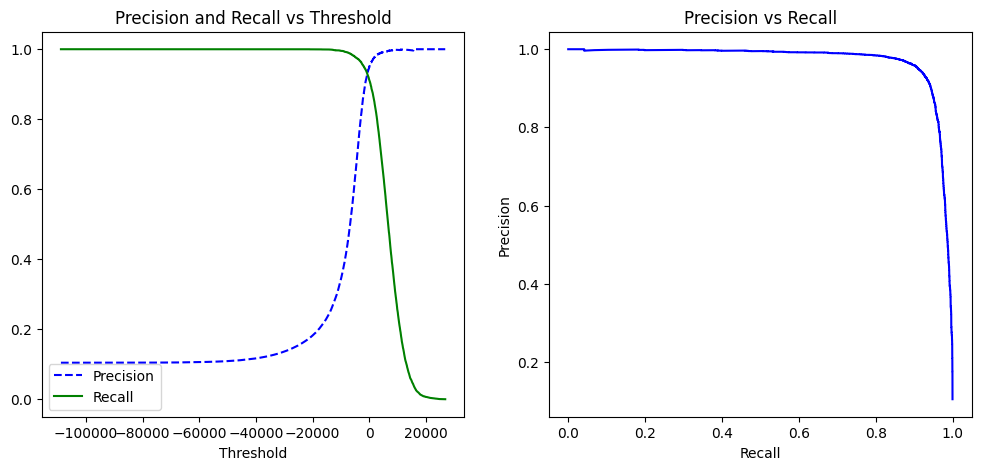

Fixed -2000 Threshold Precision: 0.8715998830067271
Fixed -2000 Threshold Recall: 0.951316839584996
Fixed 2000 Threshold Precision: 0.9783864356251164
Fixed 2000 Threshold Recall: 0.8381484437350359
Tuned Threshold Precision: 0.9771723122238586
Tuned Threshold Recall: 0.8472466081404629


In [11]:
from sklearn.metrics import precision_recall_curve

y_scores = sgdclass_model.decision_function(X_train) # [-inf, +inf]
# retorna o score de decisão para cada amostra, que é a distância da amostra ao hiperplano de decisão. 
# O threshold padrao é 0.
# Quanto maior o score, mais confiante o modelo está de que a amostra pertence à classe positiva (True).
precisions, recalls, thresholds = precision_recall_curve(y_train_7, y_scores)


_, axes = subplots = plt.subplots(1, 2, figsize=(12, 5))

# Precision x threshold e Recall x threshold são gráficos que mostram como a precisão e o recall variam em função do valor do threshold.
axes[0].plot(thresholds, precisions[:-1], "b--", label="Precision")
axes[0].plot(thresholds, recalls[:-1], "g-", label="Recall")
axes[0].set_xlabel("Threshold")
axes[0].set_title("Precision and Recall vs Threshold")
axes[0].legend()

# Precision x recall curve é um gráfico que mostra a relação entre a precisão e o recall para diferentes valores de threshold.
axes[1].plot(recalls, precisions, "b-")
axes[1].set_xlabel("Recall")
axes[1].set_ylabel("Precision")
axes[1].set_title("Precision vs Recall")
plt.show()

from sklearn.model_selection import FixedThresholdClassifier, TunedThresholdClassifierCV

# fixed -2000 threshold
fixed_threshold_clf = FixedThresholdClassifier(estimator=sgdclass_model, threshold=-2000)
fixed_threshold_clf.fit(X_train, y_train_7)
y_fixed_threshold_pred = fixed_threshold_clf.predict(X_train)
fixed_threshold_precision = precision_score(y_train_7, y_fixed_threshold_pred)
fixed_threshold_recall = recall_score(y_train_7, y_fixed_threshold_pred)

print(f"Fixed -2000 Threshold Precision: {fixed_threshold_precision}")
print(f"Fixed -2000 Threshold Recall: {fixed_threshold_recall}")

# fixed 2000 threshold
fixed_threshold_clf = FixedThresholdClassifier(estimator=sgdclass_model, threshold=2000)
fixed_threshold_clf.fit(X_train, y_train_7)
y_fixed_threshold_pred = fixed_threshold_clf.predict(X_train)
fixed_threshold_precision = precision_score(y_train_7, y_fixed_threshold_pred)
fixed_threshold_recall = recall_score(y_train_7, y_fixed_threshold_pred)
print(f"Fixed 2000 Threshold Precision: {fixed_threshold_precision}")
print(f"Fixed 2000 Threshold Recall: {fixed_threshold_recall}")

tuned_threshold_clf = TunedThresholdClassifierCV(estimator=sgdclass_model, cv=3, scoring='f1')
tuned_threshold_clf.fit(X_train, y_train_7)
y_tuned_threshold_pred = tuned_threshold_clf.predict(X_train)
tuned_threshold_precision = precision_score(y_train_7, y_tuned_threshold_pred)
tuned_threshold_recall = recall_score(y_train_7, y_tuned_threshold_pred)

print(f"Tuned Threshold Precision: {tuned_threshold_precision}")
print(f"Tuned Threshold Recall: {tuned_threshold_recall}")



**Curva ROC:** é outra métrica de qualidade em que a curva é construida usando o Recall x FPR (False positive rate)... FPR é proxy inverso da precisao pois quanto maior a quantidade de falsos positivos menor é a precisao. A cuva é construida usando as predicoes do modelo e variando o valor do threshold de 0 a 1 e plotando os pontos.

$$
FPR = \frac{FP}{FP + TN}
$$

Quanto estamos errando a classe negativa  (falsos positivos) em relação ao total de negativos (FP + TN). A curva ROC leva em consideração qualidade na classe positiva e negativa porém se as classes forem desbalanceadas (como em problemas de churn) o TN vai ser muito grande e levar o FPR para muito baixo e consequentemente o AUC vai ser maior sem necessáriamente ser. A curva PR nesse sentido é mais robusta pois analisa apenas a visão da classe positiva.

A curva diagonal representa o comportamento que um classificador aleatório teria que por exemplo: Se o threshold = 0, todos sao classificados como classe positiva -> consequencia recall = 1 (acertamos todos os positivos) e FPR = 1 (Erramos todos os negativos), Se threshold = 1, todos sao classificados como classe negativa -> consequencia recall = 0 (erramos todos os positivos) e FPR = 0 (Acertamos todos os negativos). Se o threshold é 0.5, vamos acertar 50% dos negativos e 50% dos positivos gerando entao recall = 0.5 e FPR = 0.5 e consequentemente o ponto da curva (0.5,0.5).


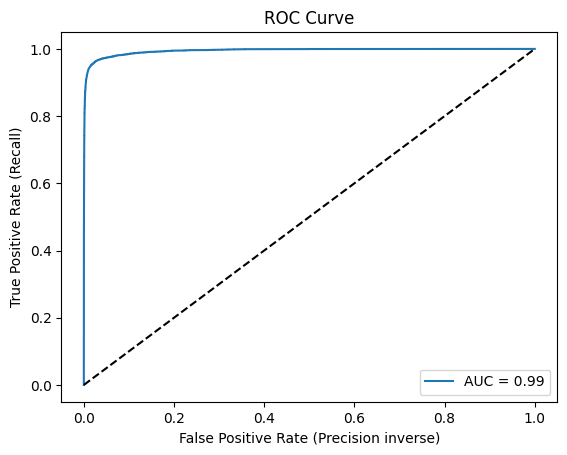

In [12]:
from sklearn.metrics import roc_curve, roc_auc_score

y_scores = sgdclass_model.decision_function(X_train)
fpr, tpr, thresholds = roc_curve(y_train_7, y_scores)
auc = roc_auc_score(y_train_7, y_scores) # AUC (Area Under the Curve) é uma métrica que representa a área sob a curva ROC. 
# representa a capacidade do modelo de distinguir entre as classes positiva e negativa. Quanto mais próximo de 1, melhor o desempenho do modelo.

plt.plot(fpr, tpr, label=f"AUC = {auc:.2f}")
plt.plot([0, 1], [0, 1], 'k--')
plt.xlabel("False Positive Rate (Precision inverse)")
plt.ylabel("True Positive Rate (Recall)")
plt.title("ROC Curve")
plt.legend()
plt.show()

### **Classificacao Multiclasse**

Classificação com várias classes objetivo... Modelos como RandomFlorest e Regressão Logistica suportam nativamente classficação multiclasse mas nem todos os tipos de modelos suportam, por exemplo SVClassifier (SVM) e SGDClassifier suportam apenas classificação binária... mas isso não é um impedidor pois existem técnicas de modelagem que permite usar eles: 
- **One vs All (OvA):** nessa modelagem treinamos um modelo para cada classe e criamos um conjunto de modelos para predição. 
- **One vs One (OvO):** nessa modelagem criamos um modelo para cada par de classes então teriamos por exemplo um modelo que classifica entre digitos 1 e 2, outro que classifica digitos 1 e 3 e assim por diante gerando n(n-1)/2 modelos (10 classes gerariam 45 modelos). A principal vantagem do OvO é que não precisamos treinar os modelos com todo o dataset de treino, apenas a parte relevante... em casos como SVM, que não escala bem com o tamanho do dataset (bom para pequenos) ele pode ser muito util pois os treinos são rápidos mas em geral a maioria dos casos é usado o OvA. 

In [ ]:
from sklearn.svm import SVC
from sklearn.multiclass import OneVsRestClassifier, OneVsOneClassifier

svm_clf = SVC(kernel='rbf', random_state=42) # aqui estamos treinando 45 modelos pois SVC usa estratégia 
# one-vs-one para classificação multiclasse, o que significa que ele treina um modelo para cada par de classes.
# a classe é escolhida com base na maioria dos votos dos modelos treinados para cada par de classes.

onevsone = OneVsOneClassifier(SVC(kernel='rbf', random_state=42)) # aqui estamos treinando 45 modelos pois OneVsOneClassifier treina um modelo para cada par de classes. (4 classes (A,B,C,D) -> 6 pares (AB, AC, AD, BC, BD, CD) -> 6 modelos)

onevsall = OneVsRestClassifier(SVC(kernel='rbf', random_state=42)) # aqui estamos treinando 10 modelos pois OneVsRestClassifier treina um modelo para cada classe.

print(len(onevsone.fit(X_train[:1000], y_train[:1000]).estimators_))
print(len(onevsall.fit(X_train[:1000], y_train[:1000]).estimators_))

45
10


#### **Error Analysis**

Após todas as etapas base de um pipeline de machine learning e ter encontrado um modelo interessante queremos otimizar ele e entender pq ele esta errando ... dependendo podemos descobrir problemas ate mesmo nos dados.

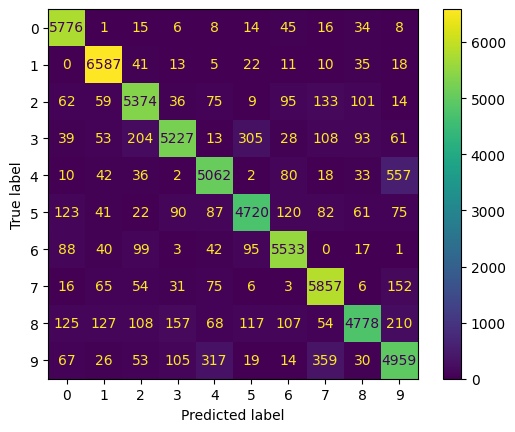

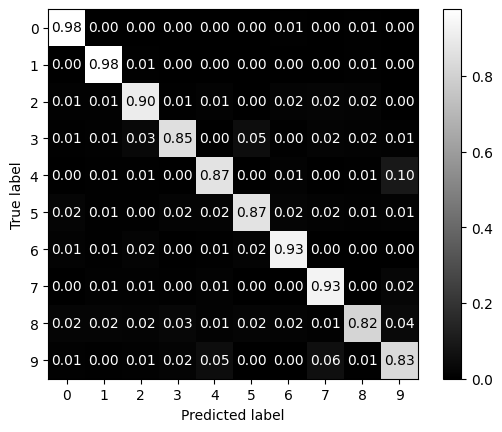

In [21]:
from sklearn.metrics import ConfusionMatrixDisplay

y_train_pred = onevsall.predict(X_train)
ConfusionMatrixDisplay.from_predictions(y_train, y_train_pred)

# normalizado pela linha, ou seja, cada valor é dividido pelo número total de amostras da classe real correspondente.
ConfusionMatrixDisplay.from_predictions(y_train, y_train_pred, normalize='true', cmap=plt.cm.gray, values_format='.2f') 

plt.show()

Com essas imagens podemos visualizar informações como que 87% dos valores que eram realmente 4 foram corretamente classificados... dos 13% que erraram, 10% foi com o digito 9, ou seja, o modelo esta confundindo bastante 4 e 9. Os outros 3% de erro foi ditribuido entre as classes 8, 6, 2 e 1... Em multiclasse não falamos mais sobre precisão e recall em geral mas sim em relação a uma classe especifica... por exemplo a precisão da classe '4' nesse exemplo é 0.88 pois 5062 / (5062 + 317 + 68 + 75 + 42 + 87 + 13 + 75 + 5 + 8) =  0.88. Uma vez identificado problemas como esse eles podem ser mitigados com mais dados de treino (que parecem ser 4 mas não são 4 para ajudar o modelo a distinguir)... ou podemos criar novas features visuais usando OpenCv por exemplo como o numero de circulos no digito ou coisas assim. 


### **Multilabel classification**

Muitas vezes queremos classificar uma instancia em mais de uma classe apenas e sim várias, por exemplo se uma foto é classificada pelos integrantes da foto, ela pode ter mais que um integrante na mesma foto e portanto fazer parte de mais de uma classe simultaneamente. Alguns algoritmos são naturalmente compativeis com problemas multilabel como por exemplo o KNN que busca os K vizinhos mais proximos e faz uma média da soma dos vetores dele e se o valor da media na coordenada do vetor de saida (classes) for grande suficiente ele vira 1, ou seja, é incluido na classe. Se deseja usar um modelo que não aceita naturalmente existem duas opções:

- **Transformar em N classificações binárias sendo N o numero de classes:** Nessa abordagem treinamos classificadores diferentes para cada classe... porém dessa maneira perdemos informação de dependencias que podem existir entre classes por exemplo uma classe B pode ser muito mais comum se ela já for da classe C. Para mitigar isso podemos usar encadeamento de classificadores:

- **ClassifierChain:** Aqui criamos um encadeamento e a saida do classificador i é usada no classificador i+1 e assim por diante até termos um um vetor de dimensão N. Vamos treinar N classificadores sequencialmente e suas saidas são concatenadas no proximo treino até termos as N saidas em que uma usa a outra como feature... logicamente a ordem das features pode alterar o resultado para mais ou menos...

Para avaliar esse tipo de classificador multilabel (e multiclasse) podemos usár as mesmas métricas recall, precisao e F1 e acurácia porém isoladamente para cada classe. E caso queira uma métrica global... fazer uma média. Usar o F1 normal iria tratar cada classe como igual mas nem sempre isso é desejado... usando o argumento 'wheighed' o F1 das classses sera ponderado pela frequencia.


In [26]:
import numpy as np
from sklearn.neighbors import KNeighborsClassifier

y_train_large =  (y_train >= '7')
y_train_odd =  (y_train.astype(int) % 2 == 1)

y_train_multilabel = np.c_[y_train_large, y_train_odd] # np.c_ é uma função do NumPy que concatena arrays ao longo do eixo das colunas (axis=1).

knn_clf = KNeighborsClassifier()
knn_clf.fit(X_train[:1000], y_train_multilabel[:1000])

y_train_multilabel_pred = knn_clf.predict(X_train[:1000])

from sklearn.multioutput import ClassifierChain

chain_clf = ClassifierChain(SVC(), order='random', random_state=42, cv=3) # multilabel model que treina um modelo para cada rótulo, e 
# cada modelo é treinado usando os rótulos anteriores como características adicionais.

chain_clf.fit(X_train[:1000], y_train_multilabel[:1000])

y_train_chain_pred = chain_clf.predict(X_train[:1000])

print("Multilabel KNN Predictions (first 5):")
print(y_train_multilabel_pred[:5])
print("\nMultilabel Classifier Chain Predictions (first 5):")
print(y_train_chain_pred[:5])


# F1 Score para multilabel classification
from sklearn.metrics import f1_score
f1_multilabel = f1_score(y_train_multilabel[:1000], y_train_multilabel_pred, average='macro')
print(f"F1 Score - Multilabel KNN: {f1_multilabel}")

# F1 Score ponderado pela frequência de cada rótulo
f1_multilabel_weighted = f1_score(y_train_multilabel[:1000], y_train_multilabel_pred, average='weighted')
print(f"F1 Score - Multilabel KNN (Weighted): {f1_multilabel_weighted}")


Multilabel KNN Predictions (first 5):
[[False  True]
 [False False]
 [False False]
 [False  True]
 [ True  True]]

Multilabel Classifier Chain Predictions (first 5):
[[0. 1.]
 [0. 0.]
 [0. 0.]
 [0. 1.]
 [1. 1.]]
F1 Score - Multilabel KNN: 0.9382181984386038
F1 Score - Multilabel KNN (Weighted): 0.9413708776936336


### **Multioutput classification**

Aqui estamos generalizando o multilabel para não apenas decisões binárias... enquanto o multilabel cada classe temos uma decisão faz parte dela (1) ou não faz parte dela (0), no multioutput essa decisão não é binária e é um problema de multiclasses por si só... imagine o output com as seguintes caracteristicas de um carro [cor, tipo de direção] nesse caso temos que cor tem as opções [verde, azul, amarelo] e direção [eletrica, mecanica e hidraulica], cada 'posição/classe' da saida é uma classificação multiclasse.

### **Estimação de probabilidade**

A saída da Sigmoide ou Softmax é uma medida de distância geométrica convertido em uma escala de 0 a 1 (um score de confiança). Chamar isso de probabilidade é errado pois, para ser, precisa refletir a frequência da realidade. O modelo pode ter muita confiança geométrica em algumas predições, mas isso não significa que a taxa de acerto real vá bater com aquele número. A calibração entra mapeando os scores de confiança na base de validação: se para um grupo de linhas com score 0.55, a realidade nos mostra que 80% delas pertenciam à classe positiva, nós mapeamos esse score para 0.80. Assim, a nova saída passa a ser uma probabilidade real de 80% de chance do evento acontecer.

A classe CalibratedClassifier do sklern cuida dessa calibração...